# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Cuestionario previo

Responder de forma breve las siguientes preguntas:

- ¿Que son las transformaciones homogéneas?
> Respuesta: Son representaciones matemáticas (matrices de 4x4) que combinan rotaciones y traslaciones en una sola matriz. Permiten describir la posición y orientación de un sistema de coordenadas respecto a otro, lo cual es fundamental para calcular la cinemática de los eslabones de un robot.

- ¿Que nos permite obtener el modelo de cinemática directa de un manipulador?
> Respuesta: Permite determinar la posición y orientación (postura) del efector final del robot en el espacio de trabajo, en función de los valores articulares (ángulos o desplazamientos) de cada una de sus juntas.

- ¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?
> Respuesta: Permite calcular los valores de las coordenadas articulares (ángulos o desplazamientos de las juntas) necesarios para que el efector final del robot alcance una posición y orientación deseadas en el espacio de trabajo. Diferenciando el modelo, también permite obtener las velocidades articulares a partir de las velocidades del efector final (usando la Inversa del Jacobiano).

- ¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?
> Respuesta: Se puede interpolar mediante polinomios de diferentes grados (ej. de tercer orden o quinto orden para asegurar suavidad en velocidad y aceleración), splines cúbicos, curvas de Bezier o trayectorias trapezoidales de velocidad, con el objetivo de generar una transición continua y suave entre el punto inicial y final.

## Desarrollo

### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano.
<img src="imagenes/p2_1.png" alt="Robot RRR" width="300" height="300" display="block"/>


In [3]:
from sympy import *
import matplotlib.pyplot as plt

class Robot():
  def __init__(self, l:tuple[float]=(0.3, 0.3, 0.3)):
    # Cinemática directa
    th1, th2, th3 = symbols("theta_1, theta_2, theta_3")
    self.th1, self.th2, self.th3 = th1, th2, th3
    
    # Transformaciones homogéneas (D-H modificado o estándar para RRR planar)
    T_0_1 = self._tr_h(x=0, alpha=self.th1)
    T_1_2 = self._tr_h(x=l[0], alpha=self.th2)
    T_2_3 = self._tr_h(x=l[1], alpha=self.th3)
    T_3_p = self._tr_h(x=l[2], alpha=0)
    
    T_0_p = simplify(T_0_1 * T_1_2 * T_2_3 * T_3_p)
    
    # Postura del Efector Final [x, y, alpha]
    xi_0_p = Matrix([T_0_p[0,3], T_0_p[1,3], self.th1 + self.th2 + self.th3])
    
    # Jacobiano analítico (derivadas parciales respecto a theta)
    J = xi_0_p.jacobian([self.th1, self.th2, self.th3])
    J_inv = J.inv()
    
    # Variables de velocidad del EF
    x_dot, y_dot, alpha_dot = symbols("x_dot, y_dot, alpha_dot")
    self.x_dot, self.y_dot, self.alpha_dot = x_dot, y_dot, alpha_dot
    
    # Vector de velocidad del efector final
    xi_0_p_dot = Matrix([x_dot, y_dot, alpha_dot])
    
    # Velocidad de las juntas en términos de la velocidad del efector final (Cinemática inversa)
    th_dot = simplify(J_inv * xi_0_p_dot)
    
    # Guardar variables
    self.xi_0_p = xi_0_p
    self.th_dot = th_dot

    # Construir una trayectoria (Polinomio de orden 5)
    t = symbols("t")
    self.t = t
    a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
    self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5
    self.lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5
    # derivadas del polinomio
    self.lam_dot = diff(self.lam, t)
    self.lam_dot_dot = diff(self.lam_dot, t)

  def def_trayectoria(self, t_f, frec, th_i=(0.1, 0.1, 0.1), xi_fn=(0.7, 0.1, 0)):
    # Postura inicial evaluando la cinemática directa con th_i
    xi_in = self.xi_0_p.subs({self.th1: th_i[0], self.th2: th_i[1], self.th3: th_i[2]}).evalf()
    self.dt = 1.0/frec
    self.muestras = int(t_f * frec + 1)
    
    # Condiciones frontera para t=0
    eq1 = self.lam.subs(self.t, 0) - 0
    eq2 = self.lam_dot.subs(self.t, 0) - 0
    eq3 = self.lam_dot_dot.subs(self.t, 0) - 0
    # Condiciones frontera para t=t_f
    eq4 = self.lam.subs(self.t, t_f) - 1
    eq5 = self.lam_dot.subs(self.t, t_f) - 0
    eq6 = self.lam_dot_dot.subs(self.t, t_f) - 0
    
    solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                    (self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5))
    
    lam_s = self.lam.subs(solutions)
    lam_dot_s = self.lam_dot.subs(solutions)
    lam_dot_dot_s = self.lam_dot_dot.subs(solutions)
    
    # Posición, velocidad y aceleración en x
    x_eq = xi_in[0] + lam_s * (xi_fn[0] - xi_in[0])
    x_dot_eq = lam_dot_s * (xi_fn[0] - xi_in[0])
    x_dot_dot_eq = lam_dot_dot_s * (xi_fn[0] - xi_in[0])
    
    # Posición, velocidad y aceleración en y
    y_eq = xi_in[1] + lam_s * (xi_fn[1] - xi_in[1])
    y_dot_eq = lam_dot_s * (xi_fn[1] - xi_in[1])
    y_dot_dot_eq = lam_dot_dot_s * (xi_fn[1] - xi_in[1])
    
    # Posición, velocidad y aceleración en alpha
    alpha_eq = xi_in[2] + lam_s * (xi_fn[2] - xi_in[2])
    alpha_dot_eq = lam_dot_s * (xi_fn[2] - xi_in[2])
    alpha_dot_dot_eq = lam_dot_dot_s * (xi_fn[2] - xi_in[2])

    # Generar arreglos para guardar muestreo
    # Tiempo
    t_m = Matrix.zeros(1, self.muestras)
    for i in range(self.muestras):
      t_m[i] = self.dt * i

    # Arreglos para posición, velocidad y aceleración del E.F.
    xi_m         = Matrix.zeros(3, self.muestras)
    xi_dot_m     = Matrix.zeros(3, self.muestras)
    xi_dot_dot_m = Matrix.zeros(3, self.muestras)
    xi_t         = Matrix([x_eq, y_eq, alpha_eq])
    xi_dot_t     = Matrix([x_dot_eq, y_dot_eq, alpha_dot_eq])
    xi_dot_dot_t = Matrix([x_dot_dot_eq, y_dot_dot_eq, alpha_dot_dot_eq])
    
    print("Muestreando trayectoria del efector final...")
    for i in range(self.muestras):
      t_val = t_m[i]
      xi_m[:, i]         = xi_t.subs(self.t, t_val).evalf()
      xi_dot_m[:, i]     = xi_dot_t.subs(self.t, t_val).evalf()
      xi_dot_dot_m[:, i] = xi_dot_dot_t.subs(self.t, t_val).evalf()

    #Arreglos para posición, velocidad y aceleración de las juntas
    th_m         = Matrix.zeros(3, self.muestras)
    th_dot_m     = Matrix.zeros(3, self.muestras)
    th_dot_dot_m = Matrix.zeros(3, self.muestras)
    # Posición inicial de las juntas
    th_m[:, 0] = Matrix([th_i[0], th_i[1], th_i[2]])
    
    print("Calculando cinemática inversa iterativamente...")
    for i in range(self.muestras):
      # Subs current joint values and end effector velocities to find joint velocities
      subs_dict = {
          self.th1: th_m[0, i], self.th2: th_m[1, i], self.th3: th_m[2, i],
          self.x_dot: xi_dot_m[0, i], self.y_dot: xi_dot_m[1, i], self.alpha_dot: xi_dot_m[2, i]
      }
      th_dot_m[:, i] = (self.th_dot.subs(subs_dict)).evalf()
      
      if i < self.muestras - 1:
        # Método de Euler para integración
        th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * self.dt
      if i > 0:
        th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1])/self.dt

    self.th_m = th_m
    self.xi_m = xi_m
    self.t_m = t_m
    
    print("Proceso completado. Generando gráficas...")
    self.graficar_xi()
    self.graficar_th()

  def graficar_xi(self):
    fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3, figsize=(15, 4))
    fig.suptitle("Posiciones del efector final")
    x_g.set_title("x")
    y_g.set_title("y")
    al_g.set_title("alpha")
    x_g.plot(self.t_m.T, self.xi_m[0, :].T, color="red")
    y_g.plot(self.t_m.T, self.xi_m[1, :].T, color="green")
    al_g.plot(self.t_m.T, self.xi_m[2, :].T, color="blue")
    x_g.grid(); y_g.grid(); al_g.grid()
    plt.show()

  def graficar_th(self):
    fig, (x_g, y_g, al_g) = plt.subplots(nrows = 1, ncols = 3, figsize=(15, 4))
    fig.suptitle("Posición de las articulaciones (Theta)")
    x_g.set_title("Theta 1")
    y_g.set_title("Theta 2")
    al_g.set_title("Theta 3")
    x_g.plot(self.t_m.T, self.th_m[0, :].T, color="red")
    y_g.plot(self.t_m.T, self.th_m[1, :].T, color="green")
    al_g.plot(self.t_m.T, self.th_m[2, :].T, color="blue")
    x_g.grid(); y_g.grid(); al_g.grid()
    plt.show()

  def _tr_h(self, x=0, y=0, z=0, gamma=0, beta=0, alpha=0):
    T_x = Matrix([[1,          0,           0, x],
                  [0, cos(gamma), -sin(gamma), 0],
                  [0, sin(gamma),  cos(gamma), 0],
                  [0,          0,           0, 1]])
    T_y = Matrix([[cos(beta),  0, sin(beta), 0],
                  [        0,  1,         0, y],
                  [-sin(beta), 0, cos(beta), 0],
                  [0, 0, 0, 1]])
    T_z = Matrix([[cos(alpha), -sin(alpha), 0, 0], 
                  [sin(alpha),  cos(alpha), 0, 0],
                  [         0,           0, 1, z], 
                  [         0,           0, 0, 1]])
    return T_x * T_y * T_z


### 4. Ejecución del modelo
Se crea la instancia del robot y se prueba la trayectoria.

Muestreando trayectoria del efector final...
Calculando cinemática inversa iterativamente...
Proceso completado. Generando gráficas...


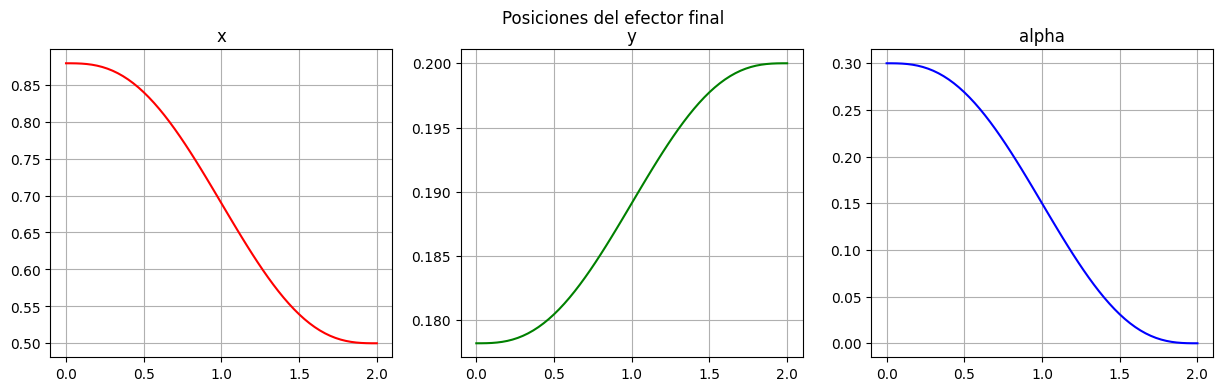

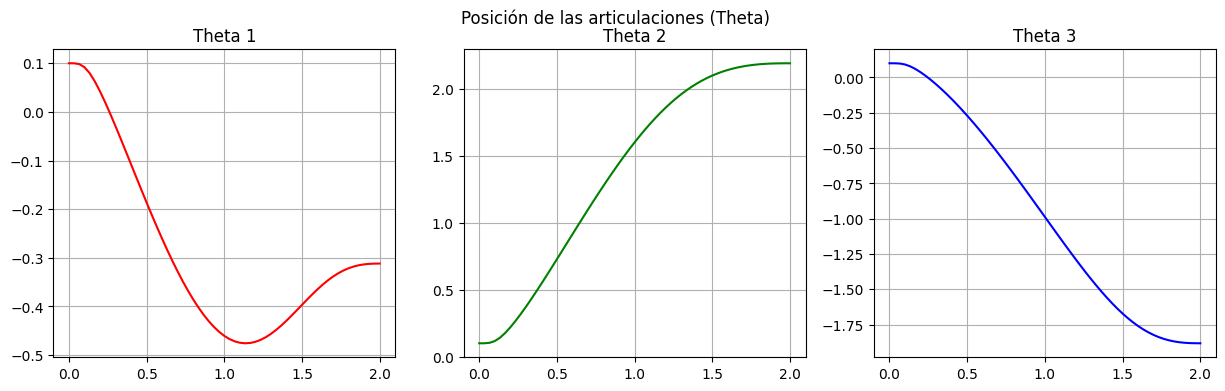

In [4]:
# Instanciar robot con longitudes l1=0.3, l2=0.3, l3=0.3
robot = Robot(l=(0.3, 0.3, 0.3))

# Se define un tiempo de 2 segundos, a 30 muestras por segundo (frec=30)
# Posición articular inicial y posición final del efector [x, y, alpha]
robot.def_trayectoria(t_f=2, frec=30, th_i=(0.1, 0.1, 0.1), xi_fn=(0.5, 0.2, 0))

## Análisis de resultados

- ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?
> Respuesta: Su utilidad principal radica en el control de movimiento y planificación de trayectorias. A diferencia de la cinemática directa (que solo nos dice dónde está el robot si conocemos sus ángulos), la cinemática inversa es lo que nos permite decirle al robot 've al punto X,Y,Z' y que el controlador matemático sepa exactamente qué ángulos enviar a los motores de cada eslabón para alcanzar ese objetivo. Sin la cinemática inversa, sería imposible programar robots en tareas industriales, ya que requeriría que un operador adivine los ángulos articulares para cada movimiento.

## Conclusiones

> Respuesta: En esta práctica se logró modelar y simular el comportamiento cinemático directo e inverso de un manipulador serial planar RRR. El uso de transformaciones homogéneas permitió encontrar la postura del efector final, y el planteamiento de una trayectoria de 5to orden (suave) permitió asegurar que los movimientos no generen impactos de aceleración o velocidad al inicio y final. Finalmente, al aplicar la cinemática inversa y métodos numéricos iterativos, se observó cómo calcular los desplazamientos necesarios en las articulaciones para seguir la trayectoria deseada en el espacio cartesiano. Las gráficas validan que los ángulos articulares se adaptan correctamente para alcanzar la postura objetivo, cumpliendo satisfactoriamente con los objetivos propuestos.

## Bibliografía 

> [1] J. J. Craig, *Introduction to Robotics: Mechanics and Control*, 3rd ed. Upper Saddle River, NJ, USA: Pearson Prentice Hall, 2005.
> [2] B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*. London, U.K.: Springer, 2009.